# Step 1:  # Step 1: Setup and MediaPipe (HandTracking)

c:\Users\ADV\Universita\Magistrale\CV\Guitar-Chords-Recognition\venv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


MediaPipe: Hand successfully detected on the fretboard.


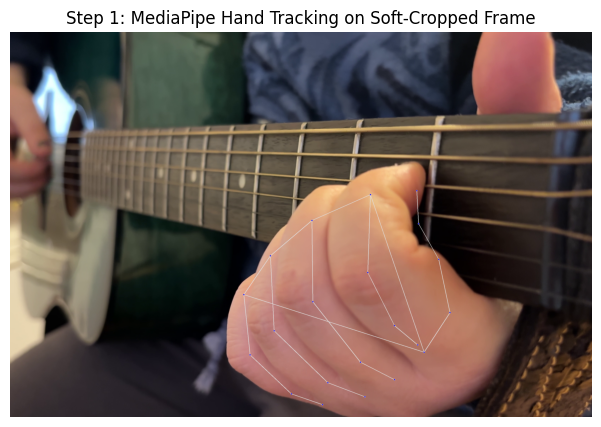

Variable 'hand_zone' successfully defined.


In [1]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
video_path = "../data/raw_videos/A_01.mp4"
target_time_sec = 6.210

# 1. EXTRACT RAW FRAME
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_MSEC, target_time_sec * 1000.0)
success, original_frame = cap.read()
cap.release()

if not success:
    raise ValueError("Error loading the video frame.")

frame_rgb = cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB)
height, width, _ = frame_rgb.shape

# 2. MEDIAPIPE TRACKING (With 15% Soft Crop to ignore picking hand)
crop_offset_x = int(width * 0.15)
soft_crop_img = frame_rgb[:, crop_offset_x:].copy()

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.1, model_complexity=1)
results = hands.process(soft_crop_img)

# Visualization
annotated_image = soft_crop_img.copy()
if results.multi_hand_landmarks:
    mp.solutions.drawing_utils.draw_landmarks(annotated_image, results.multi_hand_landmarks[0], mp_hands.HAND_CONNECTIONS)
    print("MediaPipe: Hand successfully detected on the fretboard.")
else:
    print("MediaPipe: Warning, hand not detected.")

plt.figure(figsize=(10, 5))
plt.imshow(annotated_image)
plt.title('Step 1: MediaPipe Hand Tracking on Soft-Cropped Frame')
plt.axis('off')
plt.show()

# --- ADD THIS TO DEFINE HAND_ZONE ---
hand_zone = None
if results.multi_hand_landmarks:
    hand_landmarks = results.multi_hand_landmarks[0]
    cropped_width = width - crop_offset_x
    
    # Calculate hand coordinates
    x_coords = [int(l.x * cropped_width) + crop_offset_x for l in hand_landmarks.landmark]
    y_coords = [int(l.y * height) for l in hand_landmarks.landmark]
    
    # Define the bounding box of the hand
    hand_zone = (min(x_coords), min(y_coords), max(x_coords), max(y_coords))
    print("Variable 'hand_zone' successfully defined.")

# Step 2: Sobel Y Preprocessing (Isolating Horizontal Edges)

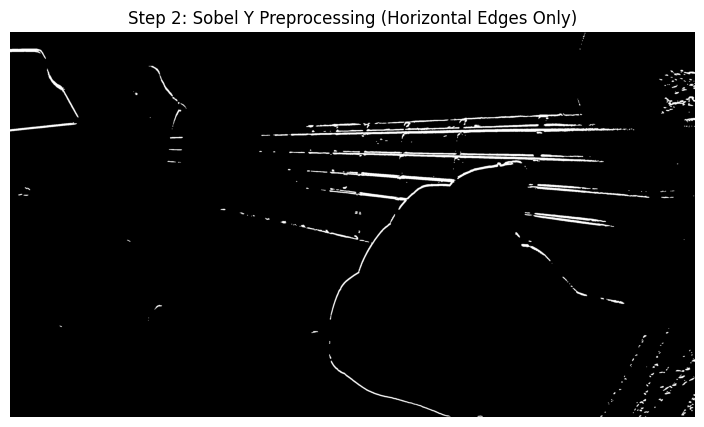

In [2]:
# 1. Convert original raw frame to grayscale
gray = cv2.cvtColor(original_frame, cv2.COLOR_BGR2GRAY)

# 2. Gaussian Blur to reduce high-frequency noise (sweater texture, wood grain)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 3. Sobel Y: The magic filter that highlights horizontal edges and kills vertical ones
sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
abs_sobel_y = cv2.convertScaleAbs(sobel_y)

# 4. Thresholding: Binarize the strongest horizontal edges
_, thresh_strings = cv2.threshold(abs_sobel_y, 40, 255, cv2.THRESH_BINARY)

# 5. Dilation: Thicken the lines slightly to repair small breaks
kernel = np.ones((3, 3), np.uint8)
preprocessed_strings = cv2.dilate(thresh_strings, kernel, iterations=1)

plt.figure(figsize=(10, 5))
plt.imshow(preprocessed_strings, cmap='gray')
plt.title('Step 2: Sobel Y Preprocessing (Horizontal Edges Only)')
plt.axis('off')
plt.show()

# Step 3: ROI (Noise and hand Removal)

Asymmetric mask applied. Y-Top extended by 180 pixels.


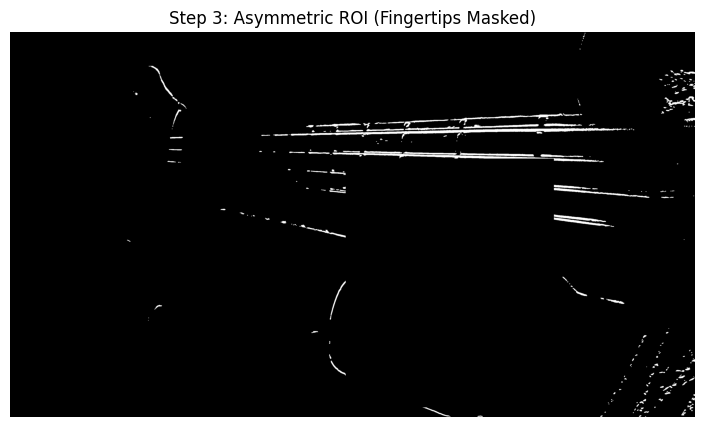

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Create a fresh copy of the preprocessed image
roi_strings = preprocessed_strings.copy()

# 1. NOISE MASK: Black out the left 15% completely 
cv2.rectangle(roi_strings, (0, 0), (crop_offset_x, height), (0, 0, 0), -1)

# 2. ASYMMETRIC SURGICAL MASK (The Fingertip Killer)
if 'results' in locals() and results.multi_hand_landmarks:
    hand_landmarks = results.multi_hand_landmarks[0]
    cropped_width = width - crop_offset_x
    
    # Map coordinates back to full image scale
    x_coords = [int(l.x * cropped_width) + crop_offset_x for l in hand_landmarks.landmark]
    y_coords = [int(l.y * height) for l in hand_landmarks.landmark]
    
    # --- ASYMMETRIC PADDING ---
    padding_x = 5           # Keep sides tight to save horizontal string length
    padding_y_top = 180      # VERY GENEROUS ON TOP: Kill the fleshy fingertips!
    padding_y_bottom = 15   # A bit of safety margin on the bottom
    
    x_min = max(0, min(x_coords) - padding_x)
    x_max = min(width, max(x_coords) + padding_x)
    y_min = max(0, min(y_coords) - padding_y_top)
    y_max = min(height, max(y_coords) + padding_y_bottom)
    
    # Draw the surgical black box
    cv2.rectangle(roi_strings, (x_min, y_min), (x_max, y_max), (0, 0, 0), -1)
    print(f"Asymmetric mask applied. Y-Top extended by {padding_y_top} pixels.")

plt.figure(figsize=(10, 5))
plt.imshow(roi_strings, cmap='gray')
plt.title('Step 3: Asymmetric ROI (Fingertips Masked)')
plt.axis('off')
plt.show()

# Step 4 (Phase A): Hough Transform (String Extraction) 

Extraction complete: Found 228 raw string segments.


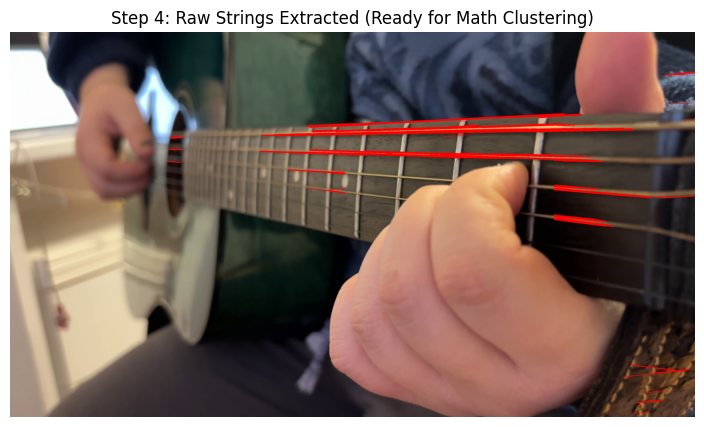

In [4]:
# Canvas for drawing the final lines
hough_strings_viz = original_frame.copy()

# Probabilistic Hough Transform optimized for long horizontal lines with gaps
lines_horizontal = cv2.HoughLinesP(
    roi_strings, 
    rho=1, 
    theta=np.pi/180, 
    threshold=35,       # Minimum votes
    minLineLength=40,   # Strings are long segments
    maxLineGap=150      # Jump over the surgical hand mask
)

raw_strings_data = [] # We will save these for the clustering phase

if lines_horizontal is not None:
    for line in lines_horizontal:
        x1, y1, x2, y2 = line[0]
        angle = np.abs(np.degrees(np.arctan2(y2 - y1, x2 - x1 + 1e-6)))
        
        # Strict filter: keep only lines perfectly horizontal (+/- 8 degrees)
        if angle < 8 or angle > 172:
            cv2.line(hough_strings_viz, (x1, y1), (x2, y2), (0, 0, 255), 2) # RED
            raw_strings_data.append(line[0])

print(f"Extraction complete: Found {len(raw_strings_data)} raw string segments.")

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(hough_strings_viz, cv2.COLOR_BGR2RGB))
plt.title('Step 4: Raw Strings Extracted (Ready for Math Clustering)')
plt.axis('off')
plt.show()

# Step 4 (Phase B) - Sobel X and ROI 

Same surgical mask applied for frets.


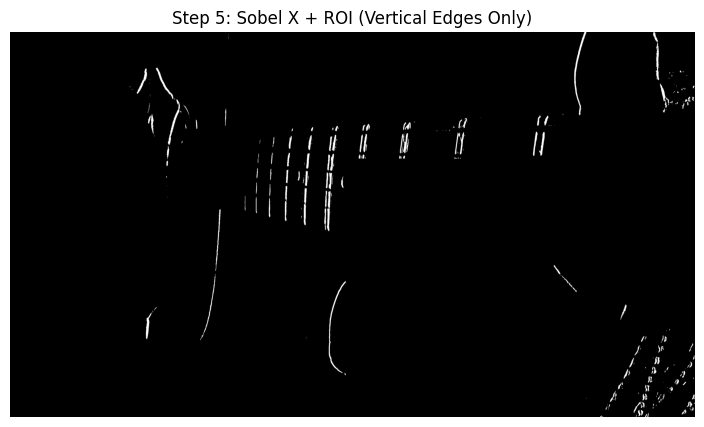

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- PHASE B: FRET EXTRACTION ---

# 1. SOBEL X: The magic filter for VERTICAL edges
# We use the 'blurred' grayscale image from Step 2
sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
abs_sobel_x = cv2.convertScaleAbs(sobel_x)

# 2. Thresholding: Binarize the strongest vertical edges
_, thresh_frets = cv2.threshold(abs_sobel_x, 40, 255, cv2.THRESH_BINARY)

# 3. Vertical Dilation: Thicken the frets slightly to heal small breaks
# We use a vertical kernel (3 rows, 1 column) so we don't accidentally merge horizontal noise
kernel_v = np.ones((3, 1), np.uint8)
preprocessed_frets = cv2.dilate(thresh_frets, kernel_v, iterations=1)

# 4. APPLY THE EXACT SAME ROI (Masking the hand and picking hand)
roi_frets = preprocessed_frets.copy()

# Black out the left 15% (Picking hand noise)
cv2.rectangle(roi_frets, (0, 0), (crop_offset_x, height), (0, 0, 0), -1)

# Black out the hand using the same coordinates (x_min, y_min, x_max, y_max) 
# that we successfully calculated in the String Extraction step
if 'results' in locals() and results.multi_hand_landmarks:
    cv2.rectangle(roi_frets, (x_min, y_min), (x_max, y_max), (0, 0, 0), -1)
    print("Same surgical mask applied for frets.")

plt.figure(figsize=(10, 5))
plt.imshow(roi_frets, cmap='gray')
plt.title('Step 5: Sobel X + ROI (Vertical Edges Only)')
plt.axis('off')
plt.show()

# Step 5: Fret Extraction 

Fret extraction complete: Found 179 valid segments.


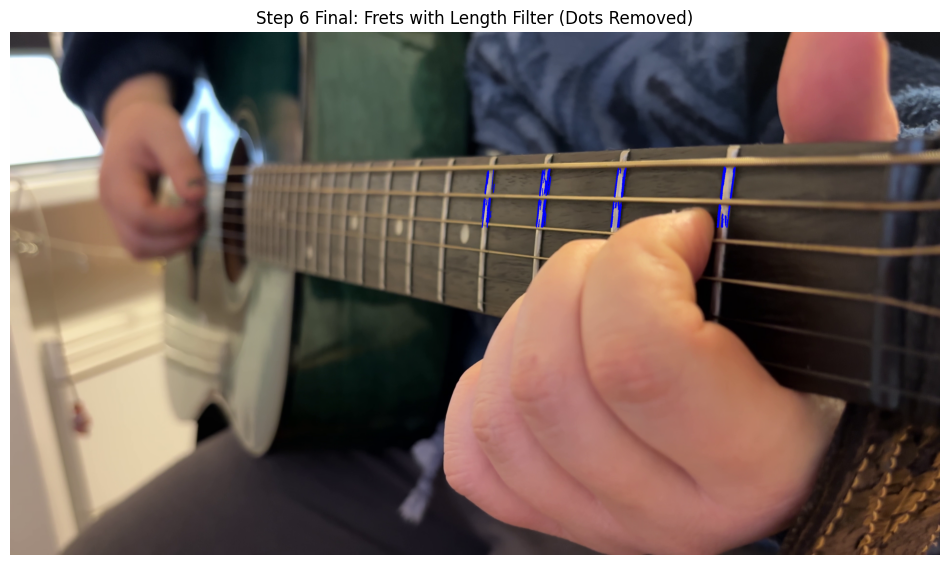

In [11]:
# --- STEP 6: REFINED FRET EXTRACTION (Anti-Noise & Length Filter) ---

hough_frets_viz = original_frame.copy()
neck_height = neck_bottom_limit - neck_top_limit

# We use the same parameters but we will filter the results in the loop
lines_vertical = cv2.HoughLinesP(
    roi_frets, 
    rho=1, 
    theta=np.pi/180, 
    threshold=25,       
    minLineLength=15,   # We keep it low to catch the "tips" above fingers
    maxLineGap=10
)

raw_frets_data = []

if lines_vertical is not None:
    for line in lines_vertical:
        x1, y1, x2, y2 = line[0]
        line_height = np.abs(y2 - y1)
        angle = np.abs(np.degrees(np.arctan2(y2 - y1, x2 - x1 + 1e-6)))
        
        # 1. STRICT VERTICAL FILTER
        if 82 < angle < 98:
            
            # 2. SMART LENGTH FILTER (The Anti-Dot Trap)
            # A real fret segment should be longer than a dot.
            # However, if it's near the fingers, it might be short.
            # We check if the line is NOT inside the hand area OR if it's long enough.
            
            is_near_hand = False
            if 'hand_zone' in locals() and hand_zone: # Using the hand_zone from the string step
                hx_min, hy_min, hx_max, hy_max = hand_zone
                is_near_hand = (hx_min - 20 < x1 < hx_max + 20)
            
            # If it's far from the hand, it MUST be at least 30% of the neck height
            # If it's near the hand, we accept it even if shorter (to catch the "tip" of the fret)
            min_allowed_height = neck_height * 0.3 if not is_near_hand else 10
            
            if line_height > min_allowed_height:
                cv2.line(hough_frets_viz, (x1, y1), (x2, y2), (255, 0, 0), 2) # BLUE
                raw_frets_data.append(line[0])

print(f"Fret extraction complete: Found {len(raw_frets_data)} valid segments.")

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(hough_frets_viz, cv2.COLOR_BGR2RGB))
plt.title('Step 6 Final: Frets with Length Filter (Dots Removed)')
plt.axis('off')
plt.show()

# Step 7: Unified Visualization

--- Day 2 Extraction Summary ---
Strings segments found: 228
Frets segments found: 179
Hand Tracking: ACTIVE


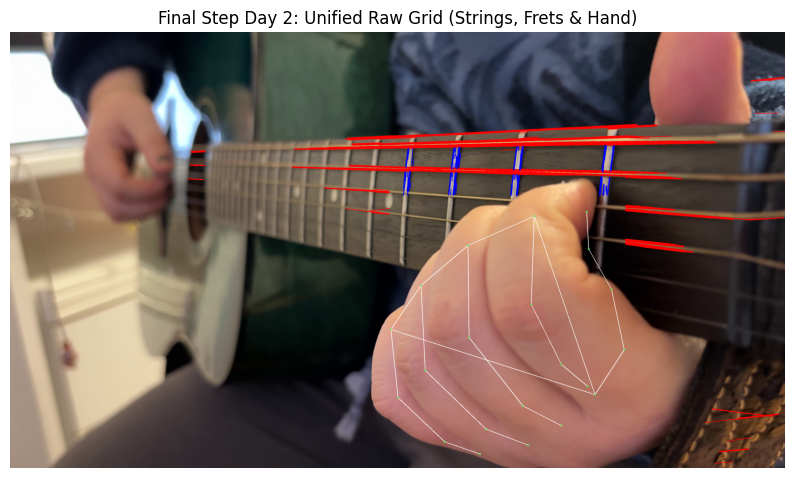

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 7: MASTER UNIFIED VISUALIZATION ---

# 1. Create a clean canvas from the original color frame
final_viz = original_frame.copy()

# 2. DRAW STRINGS (From Phase A)
# We use the raw_strings_data list we populated in Step 4
if 'raw_strings_data' in locals() and raw_strings_data:
    for line in raw_strings_data:
        x1, y1, x2, y2 = line
        cv2.line(final_viz, (x1, y1), (x2, y2), (0, 0, 255), 2) # RED for Strings

# 3. DRAW FRETS (From Phase B)
# We use the raw_frets_data list we populated in Step 6
if 'raw_frets_data' in locals() and raw_frets_data:
    for line in raw_frets_data:
        x1, y1, x2, y2 = line
        cv2.line(final_viz, (x1, y1), (x2, y2), (255, 0, 0), 2) # BLUE for Frets

# 4. DRAW HAND LANDMARKS (MediaPipe)
# This adds the context of WHERE the fingers are relative to our grid
if 'results' in locals() and results.multi_hand_landmarks:
    import mediapipe as mp
    mp_drawing = mp.solutions.drawing_utils
    mp_hands = mp.solutions.hands
    
    # We need to draw on the soft_crop area or map back to full frame
    # For simplicity, we'll draw the landmarks directly using the hand_zone logic
    for hand_landmarks in results.multi_hand_landmarks:
        # Drawing connections to see the hand structure
        mp_drawing.draw_landmarks(
            final_viz[:, crop_offset_x:], # Draw on the right portion
            hand_landmarks, 
            mp_hands.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2), # Green points
            mp_drawing.DrawingSpec(color=(255,255,255), thickness=2) # White lines
        )

# 5. PRINT SUMMARY
print(f"--- Day 2 Extraction Summary ---")
print(f"Strings segments found: {len(raw_strings_data) if 'raw_strings_data' in locals() else 0}")
print(f"Frets segments found: {len(raw_frets_data) if 'raw_frets_data' in locals() else 0}")
print(f"Hand Tracking: {'ACTIVE' if results.multi_hand_landmarks else 'NOT FOUND'}")

# 6. FINAL DISPLAY
plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(final_viz, cv2.COLOR_BGR2RGB))
plt.title('Final Step Day 2: Unified Raw Grid (Strings, Frets & Hand)')
plt.axis('off')
plt.show()

# Step 8: String Merging (Linear Regression)

Clustering complete: Merged 228 segments into 14 tilted strings.


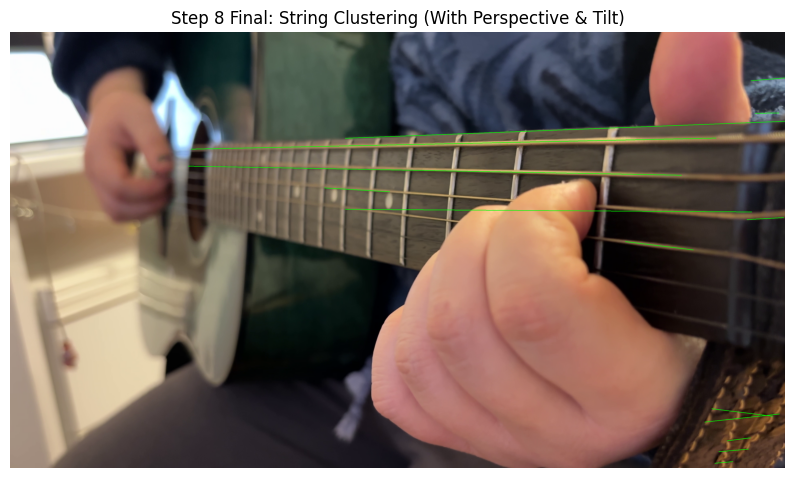

In [16]:
# --- STEP 8 REVISED: STRING CLUSTERING WITH LINEAR REGRESSION ---

def cluster_strings_with_tilt(segments, threshold=12):
    if not segments:
        return []
    
    # 1. Calculate midpoint Y for initial clustering
    y_midpoints = [(seg[1] + seg[3]) / 2 for seg in segments]
    combined = sorted(zip(y_midpoints, segments), key=lambda x: x[0])
    
    clusters = []
    if combined:
        current_cluster = [combined[0][1]]
        for i in range(1, len(combined)):
            if abs(combined[i][0] - combined[i-1][0]) <= threshold:
                current_cluster.append(combined[i][1])
            else:
                clusters.append(current_cluster)
                current_cluster = [combined[i][1]]
        clusters.append(current_cluster)
        
    merged_lines = []
    for cluster in clusters:
        # Collect all points (x1, y1) and (x2, y2) from all segments in the cluster
        all_x = []
        all_y = []
        for seg in cluster:
            all_x.extend([seg[0], seg[2]])
            all_y.extend([seg[1], seg[3]])
        
        # 2. LINEAR REGRESSION: Find the best fit line (y = mx + q)
        # np.polyfit(x, y, 1) returns [slope, intercept]
        slope, intercept = np.polyfit(all_x, all_y, 1)
        
        # Determine the full length based on the cluster's span
        x_min = min(all_x)
        x_max = max(all_x)
        
        # 3. Calculate start and end Y based on the REAL slope
        y_start = int(slope * x_min + intercept)
        y_end = int(slope * x_max + intercept)
        
        merged_lines.append([x_min, y_start, x_max, y_end])
    
    return merged_lines

# Execute the new tilted clustering
merged_strings = cluster_strings_with_tilt(raw_strings_data, threshold=12)

# Visualization
clustering_viz = original_frame.copy()
for line in merged_strings:
    # Use a thinner line (thickness=2) to see if it perfectly aligns with the red ones
    cv2.line(clustering_viz, (line[0], line[1]), (line[2], line[3]), (0, 255, 0), 2)

print(f"Clustering complete: Merged {len(raw_strings_data)} segments into {len(merged_strings)} tilted strings.")

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(clustering_viz, cv2.COLOR_BGR2RGB))
plt.title('Step 8 Final: String Clustering (With Perspective & Tilt)')
plt.axis('off')
plt.show()

# Step 9: Global Geometric Reconstruction

--- Perspective Math (Vanishing Point) ---
- Vanishing Point (Vx, Vy): (-1232, 625)
- Reference Gap at Nut (Right side): 200.68 px


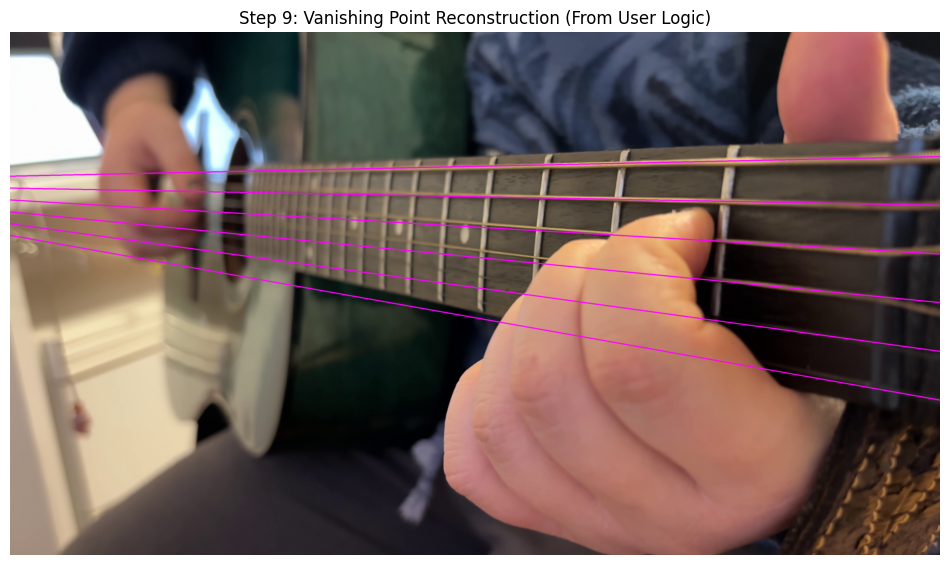

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 9: VANISHING POINT GEOMETRIC RECONSTRUCTION ---

reconstruction_viz = original_frame.copy()
h, w, _ = original_frame.shape
center_x = w // 2

# 1. EXTRACT LONG LINES (Eliminating noise, keeping only the solid ones)
long_lines_data = []
for line in merged_strings:
    x1, y1, x2, y2 = line
    if x1 == x2: continue
    
    length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    # We only keep lines longer than 35% of the screen.
    # This automatically discards noise, the broken 3rd string, and the short 4th string!
    if length > w * 0.35: 
        m = (y2 - y1) / (x2 - x1)
        q = y1 - m * x1
        y_c = m * center_x + q
        long_lines_data.append({'m': m, 'q': q, 'y_c': y_c})

# Sort lines from top to bottom
long_lines_data.sort(key=lambda x: x['y_c'])

# 2. THE PERSPECTIVE ENGINE (Using ONLY String 1 and String 2)
if len(long_lines_data) >= 3:
    # index 0: Neck edge (Ignored)
    # index 1: 1st String (Anchor 1)
    # index 2: 2nd String (Anchor 2)
    
    str1 = long_lines_data[1]
    str2 = long_lines_data[2]
    
    m1, q1 = str1['m'], str1['q']
    m2, q2 = str2['m'], str2['q']
    
    # Calculate the Vanishing Point (Intersection of String 1 and String 2)
    # Equation: m1*x + q1 = m2*x + q2
    if abs(m1 - m2) > 1e-6: # Prevent division by zero if they are perfectly parallel
        v_x = (q2 - q1) / (m1 - m2)
        v_y = m1 * v_x + q1
    else:
        v_x = -1000000 # Parallel lines meet at infinity
        v_y = str1['y_c']
        
    # Calculate the GAP at the FAR RIGHT edge of the screen (x = w)
    # This is near the nut, where the strings appear widest.
    y1_right = m1 * w + q1
    y2_right = m2 * w + q2
    gap_right = y2_right - y1_right
    
    print("--- Perspective Math (Vanishing Point) ---")
    print(f"- Vanishing Point (Vx, Vy): ({int(v_x)}, {int(v_y)})")
    print(f"- Reference Gap at Nut (Right side): {gap_right:.2f} px")

    # 3. GENERATE ALL 6 STRINGS
    final_6_strings = []
    
    for i in range(6):
        # Calculate the Y coordinate of this string at the right edge
        target_y_right = y1_right + (i * gap_right)
        
        # We need a line that passes through (v_x, v_y) and (w, target_y_right)
        m_new = (target_y_right - v_y) / (w - v_x)
        q_new = target_y_right - (m_new * w)
        
        # Find coordinates for the left edge of the screen (x = 0)
        y_start = int(q_new)
        y_end = int(target_y_right)
        
        final_6_strings.append([0, y_start, w, y_end])
        
        # Draw the generated strings in MAGENTA
        cv2.line(reconstruction_viz, (0, y_start), (w, y_end), (255, 0, 255), 3)

else:
    print("ERROR: Not enough long lines found to calculate perspective.")

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(reconstruction_viz, cv2.COLOR_BGR2RGB))
plt.title("Step 9: Vanishing Point Reconstruction (From User Logic)")
plt.axis('off')
plt.show()